In [1]:
!pip install xgboost joblib scikit-learn pandas numpy matplotlib seaborn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

Saving clean_data.csv to clean_data.csv


In [4]:
df = pd.read_csv("clean_data.csv")

df.head()

,timestamp,recipe_id,target_basis_weight,actual_basis_weight,stock_flow,filler_flow,steam_pressure,machine_speed,moisture,ash,caliper,deviation_percent,risk_level
0,2026-01-01 08:00:00,103,80,80.66,102.79,16.23,121.53,960.66,4.92,13.51,0.14,0.83,SAFE
1,2026-01-01 08:00:05,103,80,79.58,97.77,11.64,120.78,970.99,6.04,9.41,0.15,0.52,SAFE
2,2026-01-01 08:00:10,103,80,79.98,96.90,17.47,120.83,964.57,6.06,12.33,0.12,0.02,SAFE
3,2026-01-01 08:00:15,103,80,80.39,102.49,15.60,122.35,961.38,5.96,9.55,0.12,0.48,SAFE
4,2026-01-01 08:00:20,103,80,79.74,98.74,13.91,122.39,965.10,5.91,11.97,0.11,0.32,SAFE


In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

In [6]:
encoder = LabelEncoder()

df["risk_level"] = encoder.fit_transform(df["risk_level"])

for col in ["operator_action", "transition_stage"]:

    if col in df.columns:

        df[col] = LabelEncoder().fit_transform(df[col])

In [7]:
lag_columns = [

    "stock_flow",

    "steam_pressure",

    "machine_speed",

    "moisture",

    "actual_basis_weight"

]

for col in lag_columns:

    df[f"{col}_lag1"] = df[col].shift(1)

    df[f"{col}_lag2"] = df[col].shift(2)

    df[f"{col}_lag3"] = df[col].shift(3)

In [8]:
df["bw_mean_5"] = df["actual_basis_weight"].rolling(5).mean()

df["steam_mean_5"] = df["steam_pressure"].rolling(5).mean()

df["speed_mean_5"] = df["machine_speed"].rolling(5).mean()

In [9]:
FUTURE_STEPS = 60

df["future_basis_weight"] = df["actual_basis_weight"].shift(-FUTURE_STEPS)

In [10]:
df = df.dropna().reset_index(drop=True)

In [11]:
df = df.drop(columns=["timestamp"])

In [12]:
X = df.drop(columns=[

    "actual_basis_weight",

    "future_basis_weight"

])

y = df["future_basis_weight"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    shuffle=False
)

In [14]:
model = XGBRegressor(

    n_estimators=400,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [15]:
pred = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2 = r2_score(y_test, pred)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 :", r2)

MAE : 16.339914393448904
RMSE : 20.44488786392921
R2 : -0.11423793042810337


In [17]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)

importance.head(20)

,Feature,Importance
1,target_basis_weight,0.592825
0,recipe_id,0.393431
26,bw_mean_5,0.008690
11,stock_flow_lag1,0.001643
2,stock_flow,0.001392
12,stock_flow_lag2,0.000391
13,stock_flow_lag3,0.000176
23,actual_basis_weight_lag1,0.000137
17,machine_speed_lag1,0.000134
28,speed_mean_5,0.000104


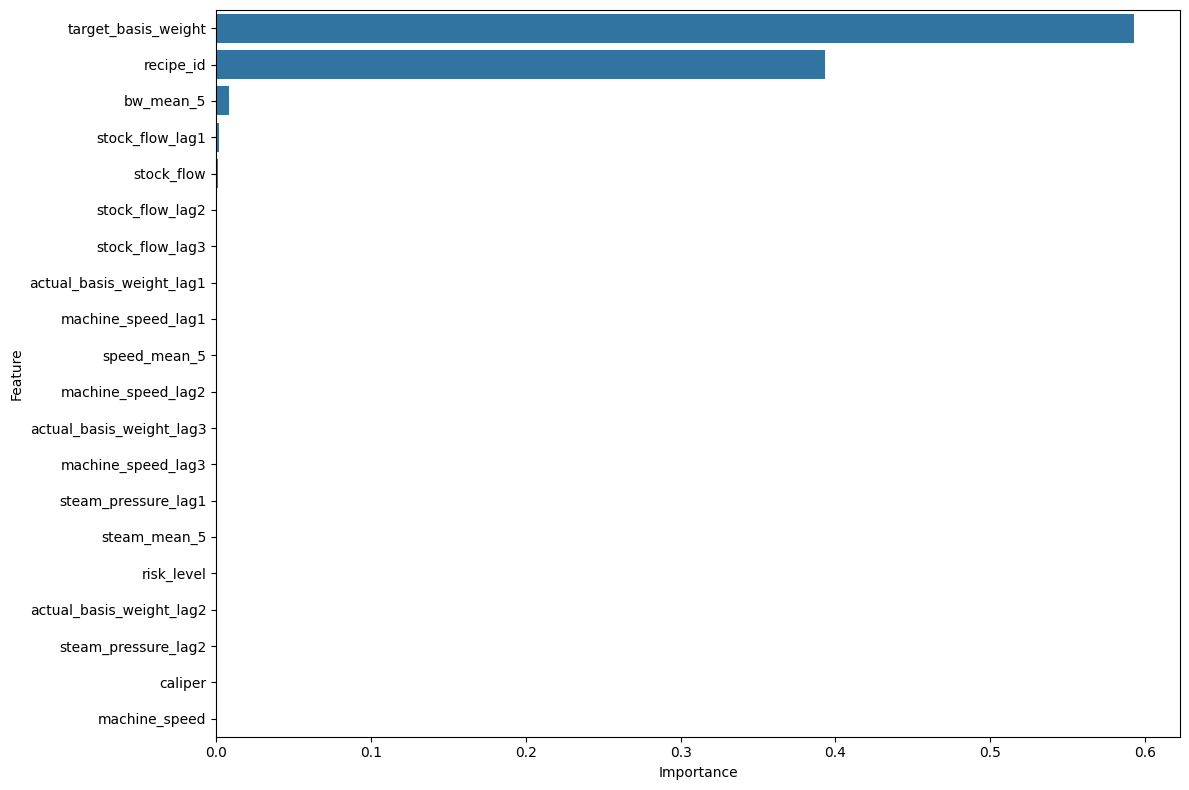

In [18]:
plt.figure(figsize=(12,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.tight_layout()

plt.savefig("feature_importance_v2.png")

plt.show()

In [19]:
joblib.dump(model, "xgboost_model_v2.pkl")

['xgboost_model_v2.pkl']

In [20]:
files.download("xgboost_model_v2.pkl")

files.download("feature_importance_v2.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>